In [151]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from sklearn.base import clone
from sklearn.pipeline import Pipeline
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from autolog import AutoLogTransform

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import ClusterCentroids

In [152]:
SEED =42
np.random.seed(SEED)

# Import Data

Column definition can be found here: https://exoplanetarchive.ipac.caltech.edu/docs/API_TOI_columns.html

In [153]:
df = pd.read_csv('TESS_Clean.csv')
df = df.drop(['rowid','toi','toipfx','tid','ctoi_alias','pl_pnum','rastr','decstr','toi_created','rowupdate'],axis=1)

df['sin_ra'] = np.sin(np.radians(df['ra']))
df['sin_dec'] = np.sin(np.radians(df['dec']))

ra_col = df.pop('ra')
dec_col = df.pop('dec')

df['disp'] = df.pop('tfopwg_disp')
df = df.dropna(subset=['disp'])
disp_map = {'APC':'PC',
            'FA':'F',
            'FP':'F',
            'KP':'C',
            'PC':'PC',
            'CP':'C'}
df['disp'] = df['disp'].map(disp_map)

df

,st_pmra,st_pmdec,pl_tranmid,pl_orbper,pl_trandurh,pl_trandep,pl_rade,pl_insol,pl_eqt,st_tmag,st_dist,st_teff,st_logg,st_rad,sin_ra,sin_dec,disp
0,-5.964,-0.076,2459229.630,2.171348,2.017220,656.886099,5.818163,22601.948580,3127.204052,9.604000,485.735,10249.0,4.19,2.169860,0.924827,-0.219777,F
1,-4.956,-15.555,2459987.949,1.931646,3.166000,1286.000000,11.215400,44464.500000,4045.000000,9.423440,295.862,7070.0,4.03,2.010000,0.842636,-0.096086,PC
2,-1.462,-2.249,2459224.688,1.867557,1.408000,1500.000000,23.752900,2860.610000,2037.000000,9.299501,943.109,8924.0,NaN,5.730000,0.967148,-0.183616,F
3,-0.939,1.640,2458493.396,2.743230,3.167000,383.410000,NaN,1177.360000,1631.000000,9.300300,7728.170,5388.5,4.15,NaN,0.936305,-0.425890,F
4,-4.496,9.347,2459987.047,3.573014,3.370000,755.000000,11.311300,54679.300000,4260.000000,9.135500,356.437,9219.0,4.14,2.150000,0.846396,-0.752447,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7926,2.061,-7.082,2458493.528,3.443800,2.572000,7260.750000,NaN,1413.670000,1708.000000,10.078100,1080.880,4805.2,NaN,NaN,0.934755,0.096938,F
7927,-3.900,3.866,2458494.778,14.537800,6.826000,4040.000000,16.052300,NaN,NaN,9.792500,379.693,8007.0,NaN,2.050000,0.871642,-0.334070,F
7928,-44.770,-2.616,2459230.149,8.413486,3.556833,17479.605330,20.510696,127.916421,857.731431,9.772700,113.667,5786.0,4.52,0.926261,0.854282,-0.862335,F
7929,-1.706,-1.714,2459229.570,0.941436,1.360700,339.912662,4.529209,41562.587810,3641.626449,9.695200,482.278,8322.0,4.01,2.349860,0.880315,-0.245626,F


# EDA

In [154]:
df.describe()

,st_pmra,st_pmdec,pl_tranmid,pl_orbper,pl_trandurh,pl_trandep,pl_rade,pl_insol,pl_eqt,st_tmag,st_dist,st_teff,st_logg,st_rad,sin_ra,sin_dec
count,7794.000000,7794.000000,7.928000e+03,7822.000000,7927.000000,7928.000000,7416.000000,7749.000000,7614.000000,7928.000000,7709.000000,7761.000000,7047.000000,7402.000000,7928.000000,7928.000000
mean,-0.573270,-8.993250,2.459601e+06,17.703768,3.069234,8209.814741,10.302941,2297.926801,1291.076512,11.578386,480.192817,5794.230849,4.304742,1.403024,0.097519,0.011069
std,76.066467,66.050805,6.492490e+02,97.301247,1.875395,17294.098827,8.445681,11078.559978,692.400302,1.625269,553.589576,1475.075201,0.303926,1.578962,0.737610,0.681461
min,-1624.050000,-1230.620000,2.457926e+06,0.152076,0.101000,24.583493,0.552507,0.000342,37.000000,4.627800,6.531270,2808.000000,0.100000,0.114827,-1.000000,-0.999957
25%,-10.514000,-14.610000,2.459204e+06,2.507959,1.847676,1431.500000,4.508725,86.763900,821.206753,10.410350,179.419000,5215.000000,4.120000,0.890000,-0.677223,-0.683095
50%,-1.548000,-3.386500,2.459632e+06,4.127538,2.740346,4740.500000,10.505330,372.358000,1188.769841,11.857100,368.055000,5803.000000,4.330000,1.236045,0.212575,0.057241
75%,8.130500,4.975250,2.460033e+06,8.084927,3.819185,10340.000000,13.974887,1193.860000,1598.000000,12.867075,651.979000,6300.000000,4.500000,1.662017,0.853386,0.683179
max,2074.520000,1048.840000,2.461048e+06,1837.889731,30.015619,767910.313100,297.111726,280833.000000,6413.000000,18.332400,14728.300000,50000.000000,5.960650,102.030000,1.000000,0.999873


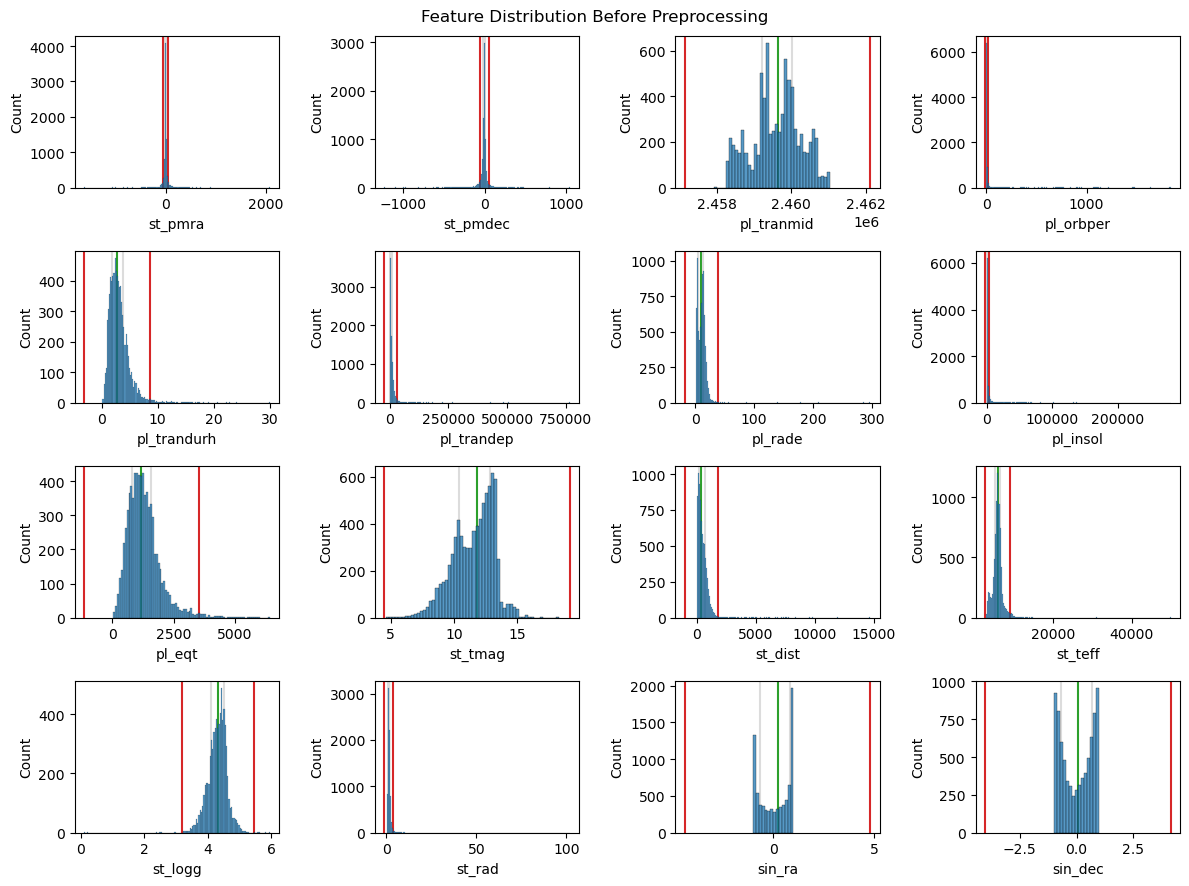

In [155]:
plt.figure(figsize=(12,9))
iqr_bound = 3
for i,col in enumerate(df.columns[:-1]):
    median = np.nanmedian(df[col])
    q3 = np.nanpercentile(df[col],75)
    q1 = np.nanpercentile(df[col],25)

    low = median - iqr_bound*(q3-q1)
    up = median + iqr_bound*(q3-q1)

    plt.subplot(4,4,i+1)
    plt.axvline(median,c='C2',zorder=1)
    plt.axvline(q1,c='gainsboro',zorder=1)
    plt.axvline(q3,c='gainsboro',zorder=1)
    plt.axvline(low,c='C3',zorder=1)
    plt.axvline(up,c='C3',zorder=1)
    sns.histplot(data=df,x=col)

plt.suptitle(f'Feature Distribution Before Preprocessing')
plt.tight_layout()
plt.show()

# Outlier Handling

In [156]:
from sklearn.base import BaseEstimator,TransformerMixin

class OutlierRemoval(BaseEstimator,TransformerMixin):
    def __init__(self,iqr_boundary=1.5,print_detail=False):
        self.iqr_boundary = iqr_boundary
        self.print_detail = print_detail

    def fit(self,X_and_y):
        X,y = X_and_y
        X = np.asarray(X,dtype=np.float32)
        median = np.nanmedian(X,axis=0)
        q3 = np.nanpercentile(X,75,axis=0)
        q1 = np.nanpercentile(X,25,axis=0)
        iqr = q3 - q1

        self.lower_ = median - self.iqr_boundary*iqr
        self.upper_ = median + self.iqr_boundary*iqr
        return self

    def transform(self,X_and_y):
        X,y = X_and_y
        X = np.asarray(X,dtype=np.float32)
        outlier_mask = (X < self.lower_) | (X > self.upper_)
        any_outlier = outlier_mask.any(axis=1)

        X_new = X[~any_outlier]
        y_new = y[~any_outlier]
        if self.print_detail:
            print(f'Removed {any_outlier.sum()} rows during outlier removal')
        return (X_new,y_new)

In [157]:
from sklearn.utils.class_weight import compute_class_weight

cls2idx = {'F':0,'C':1}
idx2cls = dict([(value,key) for (key,value) in cls2idx.items()])
classes = list(cls2idx.keys())

df_trainval = df[df['disp'] != 'PC']
X_trainval = df_trainval.drop('disp',axis=1)
y_trainval = df_trainval['disp']

X_train,X_val,y_train,y_val = train_test_split(X_trainval,y_trainval,test_size=0.2,random_state=SEED,stratify=y_trainval)
y_train = y_train.map(cls2idx)
y_val = y_val.map(cls2idx)

# Test Set
df_test = df[df['disp'] == 'PC']
X_test = df_test.drop('disp',axis=1)
y_test = df_test['disp']

# Remove Outlier
outlier = OutlierRemoval(3,print_detail=True)
X_train,y_train = outlier.fit_transform((X_train,y_train))
X_val,y_val = outlier.transform((X_val,y_val))
X_test,y_test = outlier.transform((X_test,y_test))

Removed 854 rows during outlier removal
Removed 214 rows during outlier removal
Removed 1245 rows during outlier removal


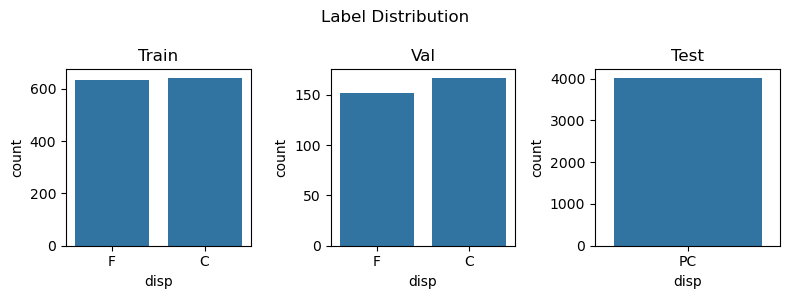

In [158]:
plt.figure(figsize=(8,3))

plt.subplot(1,3,1)
sns.countplot(x=y_train)
plt.xticks([0,1],classes)
plt.title('Train')

plt.subplot(1,3,2)
sns.countplot(x=y_val)
plt.xticks([0,1],classes)
plt.title('Val')

plt.subplot(1,3,3)
sns.countplot(x=y_test)
plt.title('Test')

plt.suptitle('Label Distribution')
plt.tight_layout()
plt.show()

In [159]:
# Transform
preprocess_pl = ImbPipeline([
    ('imputer',KNNImputer(n_neighbors=10)),
    ('autolog',AutoLogTransform(beta_multiplier=10)),
    ('scaler',StandardScaler()),
    ('pca',PCA()),
    # ('sampler',SMOTE(random_state=SEED))
])

# Model

,steps,"[('imputer', ...), ('autolog', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"missing_values missing_values: int, float, str, np.nan or None, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to np.nan, since `pd.NA` will be converted to np.nan.",nan
,"n_neighbors n_neighbors: int, default=5Number of neighboring samples to use for imputation.",10
,"weights weights: {'uniform', 'distance'} or callable, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- callable : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.",'uniform'
,"metric metric: {'nan_euclidean'} or callable, default='nan_euclidean'Distance metric for searching neighbors. Possible values:- 'nan_euclidean'- callable : a user-defined function which conforms to the definition of ``func_metric(x, y, *, missing_values=np.nan)``. `x` and `y` corresponds to a row (i.e. 1-D arrays) of `X` and `Y`, respectively. The callable should returns a scalar distance value.",'nan_euclidean'
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto theoutput of the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear on themissing indicator even if there are missing values at transform/testtime.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0`... versionadded:: 1.2",False


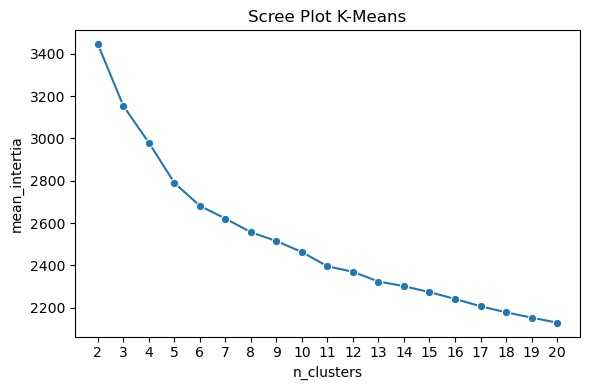

In [160]:
from sklearn.cluster import KMeans

kmeans_pl = clone(preprocess_pl)
kmeans_pl.steps.append(('kmeans',KMeans(random_state=SEED)))
display(kmeans_pl)

kmeans_grid = {
    'kmeans__n_clusters':[i+2 for i in range(19)]
}
search_kmeans = GridSearchCV(kmeans_pl,param_grid=kmeans_grid,cv=5,n_jobs=10)
search_kmeans.fit(X_train,y_train)

result_kmeans = pd.DataFrame(search_kmeans.cv_results_)[['param_kmeans__n_clusters',
                                           'mean_test_score',
                                           'std_test_score']]
result_kmeans = result_kmeans.rename(columns={'mean_test_score':'mean_intertia','std_test_score':'std_inertia','param_kmeans__n_clusters':'n_clusters'})
result_kmeans.loc[:,'mean_intertia'] = -result_kmeans['mean_intertia']
result_kmeans = result_kmeans.sort_values(by='mean_intertia',ascending=False)

plt.figure(figsize=(6,4))
sns.lineplot(result_kmeans,x='n_clusters',y='mean_intertia',marker='o')
plt.xticks(result_kmeans['n_clusters'])
plt.title('Scree Plot K-Means')
plt.tight_layout()
plt.show()

,steps,"[('imputer', ...), ('autolog', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"missing_values missing_values: int, float, str, np.nan or None, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to np.nan, since `pd.NA` will be converted to np.nan.",nan
,"n_neighbors n_neighbors: int, default=5Number of neighboring samples to use for imputation.",10
,"weights weights: {'uniform', 'distance'} or callable, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- callable : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.",'uniform'
,"metric metric: {'nan_euclidean'} or callable, default='nan_euclidean'Distance metric for searching neighbors. Possible values:- 'nan_euclidean'- callable : a user-defined function which conforms to the definition of ``func_metric(x, y, *, missing_values=np.nan)``. `x` and `y` corresponds to a row (i.e. 1-D arrays) of `X` and `Y`, respectively. The callable should returns a scalar distance value.",'nan_euclidean'
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto theoutput of the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear on themissing indicator even if there are missing values at transform/testtime.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0`... versionadded:: 1.2",False


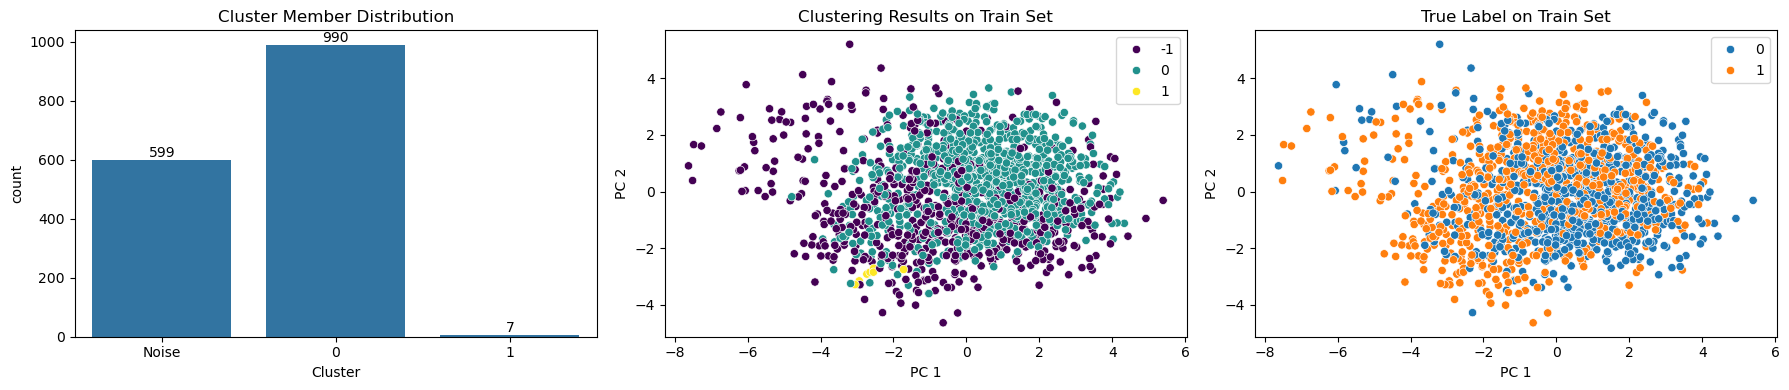

In [161]:
from sklearn.cluster import HDBSCAN

hdbscan_pl = clone(preprocess_pl)
display(hdbscan_pl)
X_hdbscan = hdbscan_pl.fit_transform(np.vstack([X_train,X_val]))
y_hdbscan = np.hstack([y_train,y_val])

hdbscan = HDBSCAN(copy=False)
hdbscan_preds_train = hdbscan.fit_predict(X_hdbscan)
clusters_unique = np.unique(hdbscan_preds_train)

plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
count = sns.countplot(x=hdbscan_preds_train)
for container in count.containers:
    count.bar_label(container)
plt.xlabel('Cluster')
plt.xticks(np.arange(len(clusters_unique)),['Noise']+[clusters_unique[i+1] for i in range(len(clusters_unique)-1)])
plt.title('Cluster Member Distribution')

plt.subplot(1,3,2)
sns.scatterplot(x=X_hdbscan[:,0],y=X_hdbscan[:,1],hue=hdbscan_preds_train,palette='viridis')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('Clustering Results on Train Set')
plt.legend()

plt.subplot(1,3,3)
sns.scatterplot(x=X_hdbscan[:,0],y=X_hdbscan[:,1],hue=y_hdbscan)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('True Label on Train Set')
plt.legend()

plt.tight_layout()
plt.show()

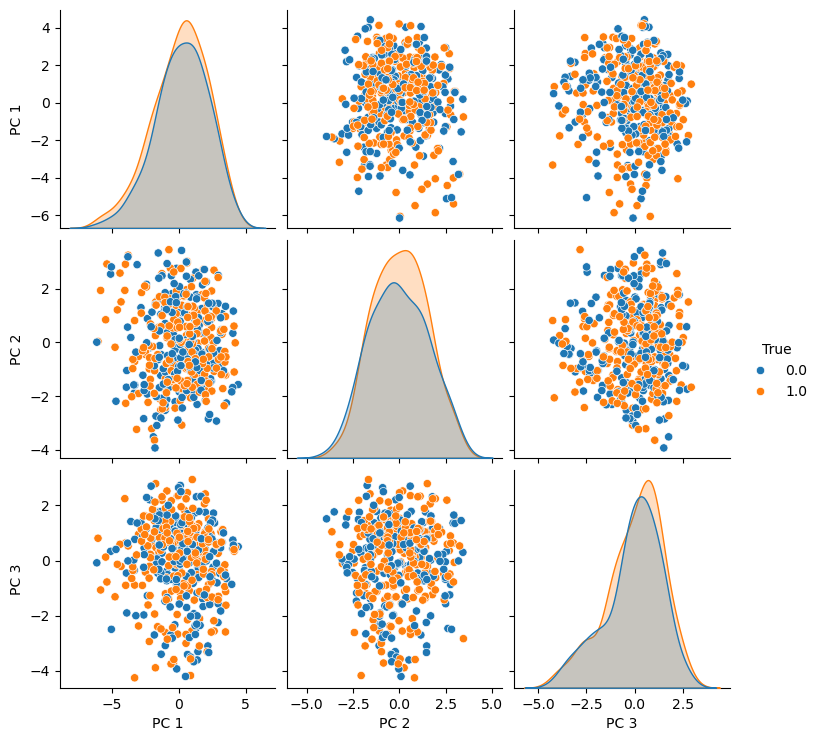

In [205]:
N = 3
CLUSTER_PCS = [f'PC {i+1}' for i in range(N)]
INSPECT = 'True'

df_cluster = pd.DataFrame(X_hdbscan[:,:N],columns=CLUSTER_PCS)
df_cluster['True'] = y_train
df_cluster['HDBSCAN'] = hdbscan_preds_train

CLUSTER_PCS.append(INSPECT)
sns.pairplot(df_cluster[CLUSTER_PCS],hue=INSPECT)
plt.show()